# 06. Error econometrics and robustness

Этот notebook завершает практический исследовательский слой курсовой. Здесь мы делаем три вещи:
- формально проверяем через простые OLS-регрессии, связаны ли ошибки модели с режимом рынка, сроком и moneyness;
- проводим robustness checks для трёх baseline-моделей;
- строим финальные простые графики и фиксируем короткий исследовательский вывод.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

## 1. Load data

Берём уже готовые результаты pricing-моделей и сравнения моделей. Основная рабочая переменная для эконометрической части - `abs_error_hv_63d`, потому что именно `hv_63d` оказался лучшим простым baseline.

In [2]:
project_root = Path('/Users/maria/Desktop/Code/HSE/COURSEBOOK')
results_dir = project_root / 'results'
figures_dir = results_dir / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

baseline = pd.read_parquet(results_dir / 'model_pricing_baseline.parquet')
garch = pd.read_parquet(results_dir / 'model_pricing_garch.parquet')
comparison_summary = pd.read_csv(results_dir / 'model_comparison_summary.csv')
comparison_by_vol = pd.read_csv(results_dir / 'model_comparison_by_vol_regime.csv')

keep_garch = [
    'SECID', 'TRADEDATE', 'model_price_garch', 'error_garch', 'abs_error_garch', 'pct_error_garch', 'squared_error_garch'
]
df = baseline.merge(garch[keep_garch], on=['SECID', 'TRADEDATE'], how='left')
df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'], errors='coerce')
df.shape

(19327, 55)

## 2. Why OLS here?

Здесь OLS не используется как структурная модель цены опциона. Его роль намного скромнее: это просто формальный тест, связаны ли ошибки ценообразования с режимом рынка, сроком до экспирации и степенью отклонения от `ATM`.

Если коэффициенты значимы и имеют ожидаемый знак, это усиливает наши исследовательские выводы из descriptive analysis.

## 3. Prepare variables

Подготовим минимальный набор регрессоров:
- `high_vol_dummy`
- `abs_log_moneyness`
- `option_type` dummy, если есть
- `trend_regime` dummies, если есть

Также заново создадим `moneyness`-bucket и `DTE`-bucket для robustness checks.

In [3]:
df['high_vol_dummy'] = (df['vol_regime'] == 'high_vol').astype(int)
df['abs_log_moneyness'] = df['log_moneyness'].abs()

if 'option_type' in df.columns:
    df['option_type_dummy'] = (df['option_type'].astype(str).str.upper() == 'C').astype(int)

df['moneyness_bucket_5'] = pd.cut(
    df['moneyness'],
    bins=[0, 0.9, 0.97, 1.03, 1.1, np.inf],
    labels=['deep_OTM', 'OTM', 'ATM', 'ITM', 'deep_ITM'],
)

df['DTE_bucket_4'] = pd.cut(
    df['DTE_DAYS'],
    bins=[0, 7, 30, 90, np.inf],
    labels=['0-7', '8-30', '31-90', '91+'],
)

ols_df = df[['abs_error_hv_63d', 'high_vol_dummy', 'DTE_DAYS', 'abs_log_moneyness', 'trend_regime', 'option_type']].dropna().copy()
ols_df.shape

(18077, 6)

## 4. OLS regressions

Оценим три простые спецификации. Везде используем `HC3` robust standard errors, чтобы не полагаться на строгую гомоскедастичность.

Главный фокус:
- положителен ли коэффициент при `high_vol_dummy`;
- значимы ли `DTE_DAYS` и `abs_log_moneyness`;
- сохраняются ли результаты после добавления дополнительных control variables.

In [4]:
model_1 = smf.ols('abs_error_hv_63d ~ high_vol_dummy', data=ols_df).fit(cov_type='HC3')
model_2 = smf.ols('abs_error_hv_63d ~ high_vol_dummy + DTE_DAYS + abs_log_moneyness', data=ols_df).fit(cov_type='HC3')
model_3 = smf.ols('abs_error_hv_63d ~ high_vol_dummy + DTE_DAYS + abs_log_moneyness + C(trend_regime) + C(option_type)', data=ols_df).fit(cov_type='HC3')

print(model_1.summary())
print(model_2.summary())
print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:       abs_error_hv_63d   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     940.5
Date:                Tue, 26 May 2026   Prob (F-statistic):          2.18e-201
Time:                        13:42:11   Log-Likelihood:            -1.2867e+05
No. Observations:               18077   AIC:                         2.574e+05
Df Residuals:                   18075   BIC:                         2.574e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        260.4489      2.613     99.

**Интерпретация.** В самой простой регрессии `high_vol_dummy` имеет сильный положительный и статистически значимый коэффициент: в high-volatility режиме ошибки baseline выше. После добавления `DTE` и `abs_log_moneyness` эффект high-vol заметно ослабевает, что говорит о частичном overlap между режимом рынка и структурой поверхности опционов. При этом `DTE_DAYS` и `abs_log_moneyness` устойчиво положительны и значимы, значит более длинные опционы и более крайние значения moneyness действительно связаны с большими ошибками модели.

## 5. Robustness checks

Теперь сравним три модели на нескольких выборках:
- полный sample;
- без крайних хвостов `deep_OTM` и `deep_ITM`;
- только короткие опционы `DTE <= 91`.

Также добавим `mean absolute pct_error`, чтобы посмотреть на устойчивость результатов в относительных единицах.

In [5]:
models = {
    'hv_21d': {'model': 'model_price_hv_21d', 'err': 'error_hv_21d', 'abs': 'abs_error_hv_21d', 'sq': 'squared_error_hv_21d', 'pct': 'pct_error_hv_21d'},
    'hv_63d': {'model': 'model_price_hv_63d', 'err': 'error_hv_63d', 'abs': 'abs_error_hv_63d', 'sq': 'squared_error_hv_63d', 'pct': 'pct_error_hv_63d'},
    'garch': {'model': 'model_price_garch', 'err': 'error_garch', 'abs': 'abs_error_garch', 'sq': 'squared_error_garch', 'pct': 'pct_error_garch'},
}


def calc_metrics(frame, cols):
    sub = frame.loc[frame[cols['model']].notna()].copy()
    return {
        'N': int(len(sub)),
        'MAE': float(sub[cols['abs']].mean()),
        'RMSE': float(np.sqrt(sub[cols['sq']].mean())),
        'mean_error': float(sub[cols['err']].mean()),
        'median_abs_error': float(sub[cols['abs']].median()),
        'mean_abs_pct_error': float(sub[cols['pct']].abs().mean()),
    }


robustness_rows = []
samples = {
    'full_sample': df,
    'exclude_deep_tails': df.loc[~df['moneyness_bucket_5'].astype(str).isin(['deep_OTM', 'deep_ITM'])].copy(),
    'short_dte_le_91': df.loc[df['DTE_DAYS'] <= 91].copy(),
}

for model_name, cols in models.items():
    for sample_name, sample_df in samples.items():
        row = {'model': model_name, 'sample': sample_name}
        row.update(calc_metrics(sample_df, cols))
        robustness_rows.append(row)

robustness_table = pd.DataFrame(robustness_rows)
robustness_table

,model,sample,N,MAE,RMSE,mean_error,median_abs_error,mean_abs_pct_error
0,hv_21d,full_sample,18926,326.288671,452.591519,-309.581680,216.694544,4.604059
1,hv_21d,exclude_deep_tails,9952,294.399483,406.464909,-270.727190,180.555209,5.541987
2,hv_21d,short_dte_le_91,2779,43.872093,61.536709,-40.568523,30.378972,0.658561
3,hv_63d,full_sample,18077,308.996963,435.453098,-292.995101,192.985502,4.001795
4,hv_63d,exclude_deep_tails,9605,269.080382,378.487220,-245.673774,150.067064,4.848168
5,hv_63d,short_dte_le_91,2779,43.094728,59.689981,-38.653624,31.421957,0.662137
6,garch,full_sample,19291,326.790071,455.043486,-309.247668,215.582125,4.436261
7,garch,exclude_deep_tails,10106,297.859113,412.253488,-272.717083,181.094868,5.376300
8,garch,short_dte_le_91,2779,41.501179,58.729174,-37.458724,27.697204,0.662004


**Интерпретация.** `hv_63d` остаётся лучшим baseline и в robustness checks. После исключения крайних хвостов и особенно при ограничении выборки короткими опционами ошибки заметно падают у всех моделей. Это подтверждает, что основные проблемы pricing baseline сосредоточены в хвостах smile и на длинных maturities.

## 6. Final plots

Построим четыре простых графика и сохраним их в `results/figures/`. Они нужны как компактная визуальная поддержка выводов из таблиц.

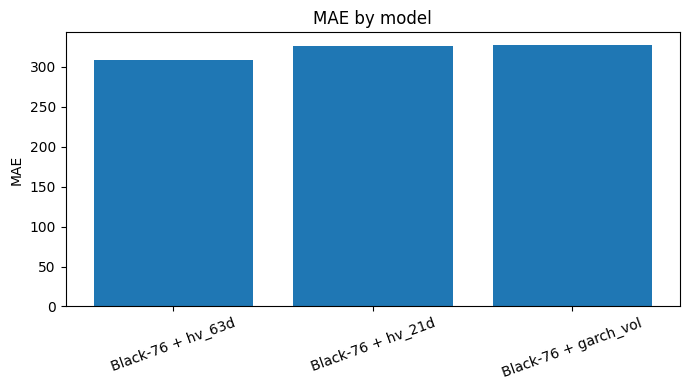

In [6]:
mae_by_model = comparison_summary.copy()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(mae_by_model['model'], mae_by_model['MAE'])
ax.set_title('MAE by model')
ax.set_ylabel('MAE')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(figures_dir / 'mae_by_model.png', dpi=150)
plt.show()

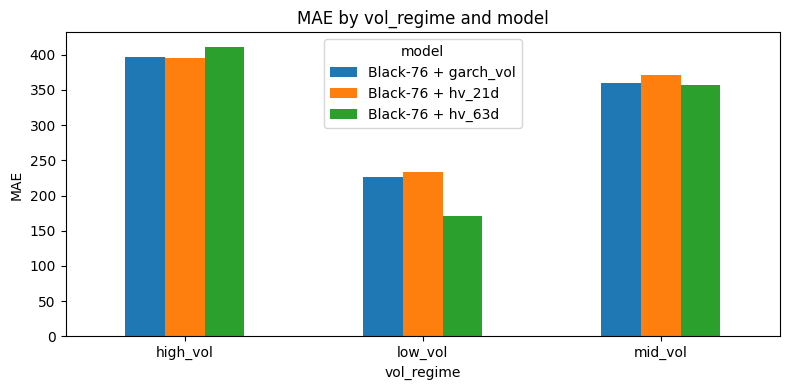

In [7]:
plot_vol = comparison_by_vol.dropna(subset=['vol_regime']).copy()
pivot_vol = plot_vol.pivot(index='vol_regime', columns='model', values='MAE')

fig, ax = plt.subplots(figsize=(8, 4))
pivot_vol.plot(kind='bar', ax=ax)
ax.set_title('MAE by vol_regime and model')
ax.set_ylabel('MAE')
ax.tick_params(axis='x', rotation=0)
fig.tight_layout()
fig.savefig(figures_dir / 'mae_by_vol_regime_model.png', dpi=150)
plt.show()

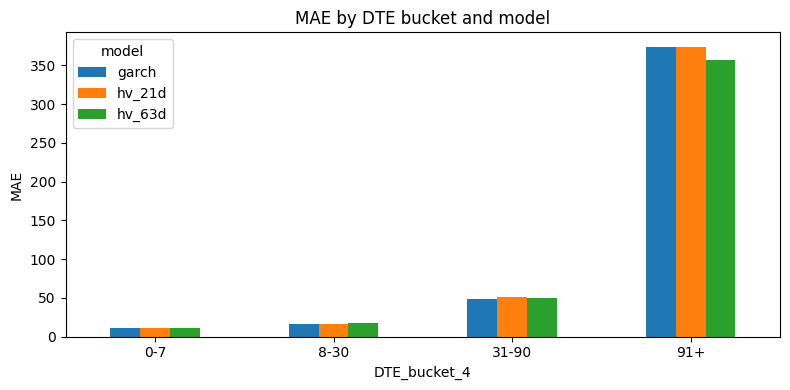

In [8]:
dte_rows = []
for model_name, cols in models.items():
    sub = df.loc[df[cols['model']].notna()].copy()
    temp = sub.groupby('DTE_bucket_4', dropna=False, observed=False)[cols['abs']].mean().reset_index(name='MAE')
    temp['model'] = model_name
    dte_rows.append(temp)
dte_plot_df = pd.concat(dte_rows, ignore_index=True)
pivot_dte = dte_plot_df.dropna(subset=['DTE_bucket_4']).pivot(index='DTE_bucket_4', columns='model', values='MAE')

fig, ax = plt.subplots(figsize=(8, 4))
pivot_dte.plot(kind='bar', ax=ax)
ax.set_title('MAE by DTE bucket and model')
ax.set_ylabel('MAE')
ax.tick_params(axis='x', rotation=0)
fig.tight_layout()
fig.savefig(figures_dir / 'mae_by_dte_bucket_model.png', dpi=150)
plt.show()

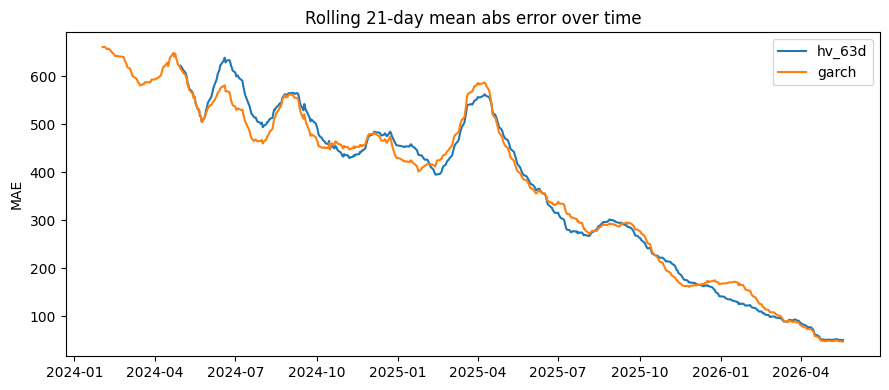

In [9]:
rolling = (
    df.groupby('TRADEDATE')[['abs_error_hv_63d', 'abs_error_garch']]
    .mean()
    .rolling(21)
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(rolling['TRADEDATE'], rolling['abs_error_hv_63d'], label='hv_63d')
ax.plot(rolling['TRADEDATE'], rolling['abs_error_garch'], label='garch')
ax.set_title('Rolling 21-day mean abs error over time')
ax.set_ylabel('MAE')
ax.legend()
fig.tight_layout()
fig.savefig(figures_dir / 'rolling_abs_error_hv63d_vs_garch.png', dpi=150)
plt.show()

**Интерпретация.** Графики подтверждают картину из таблиц: `hv_63d` остаётся лучшим простым baseline, а все модели заметно хуже работают в `high_vol` regime и на длинных `DTE`. Динамика rolling error также показывает, что периоды роста ошибок совпадают с более напряжёнными фазами рынка.

## 7. Final conclusion

- `hv_63d` остаётся лучшим baseline overall.
- `GARCH` не улучшает pricing quality в этом MVP.
- `high_vol` regime связан с ростом pricing errors.
- Ошибки выше для extreme moneyness и long DTE, что подтверждается и descriptive analysis, и OLS.
- Следовательно, `Black-76` с простыми volatility inputs полезен как baseline benchmark, но его недостаточно для полного описания рыночных цен опционов.

## 8. Save outputs

Сохраним текст результатов OLS, итоговую robustness table и короткий markdown summary для использования в тексте курсовой.

In [10]:
ols_text = []
ols_text.append('MODEL 1\n')
ols_text.append(model_1.summary().as_text())
ols_text.append('\n\nMODEL 2\n')
ols_text.append(model_2.summary().as_text())
ols_text.append('\n\nMODEL 3\n')
ols_text.append(model_3.summary().as_text())

error_ols_path = results_dir / 'error_ols_results.txt'
robustness_path = results_dir / 'robustness_checks.csv'
summary_md_path = results_dir / 'final_research_summary.md'

error_ols_path.write_text(''.join(ols_text))
robustness_table.to_csv(robustness_path, index=False)

summary_md = '''# Final Research Summary

- Лучший простой baseline по итогам сравнения моделей: `Black-76 + hv_63d`.
- `GARCH` в текущем MVP не дал улучшения по `MAE` и `RMSE` относительно `hv_63d`.
- Ошибки моделей растут в `high_vol` regime.
- Ошибки выше на длинных `DTE` и в крайних сегментах moneyness.
- OLS-проверка подтверждает, что `DTE` и `abs_log_moneyness` статистически связаны с размером pricing error.
- Значит `Black-76` с простыми volatility inputs полезен как baseline benchmark, но не полностью описывает рыночную поверхность опционов.
- Следующий естественный шаг: implied-vol benchmark или более сильная volatility / surface model.
'''
summary_md_path.write_text(summary_md)

print('Saved:', error_ols_path)
print('Saved:', robustness_path)
print('Saved:', summary_md_path)
print('Saved figures to:', figures_dir)

Saved: /Users/maria/Desktop/Code/HSE/COURSEBOOK/results/error_ols_results.txt
Saved: /Users/maria/Desktop/Code/HSE/COURSEBOOK/results/robustness_checks.csv
Saved: /Users/maria/Desktop/Code/HSE/COURSEBOOK/results/final_research_summary.md
Saved figures to: /Users/maria/Desktop/Code/HSE/COURSEBOOK/results/figures
